In [1]:
import json
import random
import site
import sys
from pathlib import Path

extra_site = site.getusersitepackages()
if extra_site and extra_site not in sys.path:
    sys.path.insert(0, extra_site)

import joblib
import librosa
import numpy as np
import pandas as pd
import soundfile as sf
from scipy import signal
from scipy.fft import dct
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, f1_score, precision_score, recall_score, r2_score
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

ROOT = Path.cwd()
if not (ROOT / "Data").exists() and (ROOT.parent / "Data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "Data"
MODELS_DIR = ROOT / "Models"
MODELS_DIR.mkdir(exist_ok=True)

SEED = 42
TARGET_SR = 16000
EPS = 1e-10

random.seed(SEED)
np.random.seed(SEED)


In [2]:
def load_audio(path):
    try:
        audio, sr = sf.read(path, always_2d=False)
        if getattr(audio, "ndim", 1) == 2:
            audio = audio.mean(axis=1)
        audio = np.asarray(audio, dtype=np.float32)
    except Exception:
        audio, sr = librosa.load(path, sr=None, mono=True)
        audio = np.asarray(audio, dtype=np.float32)
    if sr != TARGET_SR:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=TARGET_SR)
    peak = float(np.max(np.abs(audio))) if audio.size else 0.0
    if peak > 0:
        audio = audio / peak
    return audio

def trim_silence(audio, ratio=0.02):
    if audio.size == 0:
        return audio
    peak = float(np.max(np.abs(audio)))
    if peak <= 0:
        return audio
    idx = np.flatnonzero(np.abs(audio) >= peak * ratio)
    if idx.size == 0:
        return audio
    return audio[idx[0]:idx[-1] + 1]

def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)

def mel_to_hz(mel):
    return 700.0 * (10 ** (mel / 2595.0) - 1.0)

def mel_filterbank(sample_rate, n_fft, n_mels=40):
    mel_points = np.linspace(hz_to_mel(np.array([0.0]))[0], hz_to_mel(np.array([sample_rate / 2.0]))[0], n_mels + 2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((n_fft + 1) * hz_points / sample_rate).astype(int)
    filters = np.zeros((n_mels, n_fft // 2 + 1), dtype=np.float32)
    for i in range(1, n_mels + 1):
        left = bins[i - 1]
        center = max(bins[i], left + 1)
        right = max(bins[i + 1], center + 1)
        filters[i - 1, left:center] = np.linspace(0.0, 1.0, center - left, endpoint=False)
        filters[i - 1, center:right] = np.linspace(1.0, 0.0, right - center, endpoint=False)
    return filters

def quick_stats(values):
    values = np.asarray(values, dtype=np.float32)
    if values.size == 0:
        return [0.0, 0.0, 0.0, 0.0]
    return [
        float(np.mean(values)),
        float(np.std(values)),
        float(np.percentile(values, 10)),
        float(np.percentile(values, 90)),
    ]

def run_lengths(mask):
    if mask.size == 0:
        return np.asarray([], dtype=np.int32), np.asarray([], dtype=bool)
    change = np.flatnonzero(np.diff(mask.astype(np.int8))) + 1
    starts = np.concatenate(([0], change))
    ends = np.concatenate((change, [mask.size]))
    lengths = ends - starts
    return lengths.astype(np.int32), mask[starts].astype(bool)

def extract_features(audio):
    audio = trim_silence(audio)
    if audio.size < TARGET_SR // 2:
        audio = np.pad(audio, (0, TARGET_SR // 2 - audio.size))
    pre = np.append(audio[:1], audio[1:] - 0.97 * audio[:-1])
    frame_len = 400
    overlap = 240
    n_fft = 512
    freqs, _, stft = signal.stft(
        pre,
        fs=TARGET_SR,
        window="hann",
        nperseg=frame_len,
        noverlap=overlap,
        nfft=n_fft,
        boundary=None,
        padded=False,
    )
    mag = np.abs(stft) + EPS
    power = mag ** 2
    padded = np.pad(pre, (0, max(0, frame_len - pre.size % frame_len)))
    frames = np.lib.stride_tricks.sliding_window_view(padded, frame_len)[:: max(1, frame_len - overlap)]
    if frames.shape[0] > mag.shape[1]:
        frames = frames[:mag.shape[1]]
    elif frames.shape[0] < mag.shape[1]:
        gap = mag.shape[1] - frames.shape[0]
        frames = np.vstack([frames, np.zeros((gap, frame_len), dtype=frames.dtype)])
    rms = np.sqrt(np.mean(frames ** 2, axis=1) + EPS)
    zcr = np.mean(np.abs(np.diff(np.signbit(frames), axis=1)), axis=1)
    vad = rms >= max(float(np.percentile(rms, 35)), float(np.max(rms) * 0.12))
    lengths, flags = run_lengths(vad)
    frame_seconds = (frame_len - overlap) / TARGET_SR
    voiced = lengths[flags] * frame_seconds
    pauses = lengths[~flags] * frame_seconds
    spec_sum = np.sum(mag, axis=0) + EPS
    centroid = np.sum(freqs[:, None] * mag, axis=0) / spec_sum
    bandwidth = np.sqrt(np.sum(((freqs[:, None] - centroid[None, :]) ** 2) * mag, axis=0) / spec_sum)
    cumulative = np.cumsum(power, axis=0)
    total = cumulative[-1, :] + EPS
    rolloff_85 = freqs[np.argmax(cumulative >= total * 0.85, axis=0)]
    flatness = np.exp(np.mean(np.log(power), axis=0)) / (np.mean(power, axis=0) + EPS)
    fb = mel_filterbank(TARGET_SR, n_fft, n_mels=40)
    mel = fb @ power
    log_mel = np.log(mel + EPS)
    mfcc = dct(log_mel, type=2, axis=0, norm="ortho")[:13, :]
    delta = np.diff(mfcc, axis=1, prepend=mfcc[:, :1])
    small_mel = signal.resample(log_mel, 24, axis=1)
    small_mel = (small_mel - np.mean(small_mel)) / (np.std(small_mel) + EPS)
    values = []
    values.extend(
        [
            float(len(audio) / TARGET_SR),
            float(np.mean(np.abs(audio))),
            float(np.std(audio)),
            float(np.max(np.abs(audio))),
            float(np.mean(vad)),
        ]
    )
    for vec in [rms, zcr, centroid, bandwidth, rolloff_85, flatness, voiced, pauses]:
        values.extend(quick_stats(vec))
    for matrix in [mfcc, delta]:
        values.extend(np.mean(matrix, axis=1).astype(float).tolist())
        values.extend(np.std(matrix, axis=1).astype(float).tolist())
    values.extend(small_mel.astype(float).reshape(-1).tolist())
    return np.asarray(values, dtype=np.float32)

def chunk_audio(audio, chunk_seconds=10, hop_seconds=5, max_chunks=8):
    chunk_len = int(chunk_seconds * TARGET_SR)
    hop_len = int(hop_seconds * TARGET_SR)
    audio = trim_silence(audio)
    if audio.size < chunk_len:
        audio = np.pad(audio, (0, chunk_len - audio.size))
    chunks = []
    for start in range(0, max(1, audio.size - chunk_len + 1), hop_len):
        piece = audio[start:start + chunk_len]
        if piece.size < chunk_len:
            piece = np.pad(piece, (0, chunk_len - piece.size))
        chunks.append(piece.astype(np.float32))
        if len(chunks) >= max_chunks:
            break
    if not chunks:
        chunks = [audio[:chunk_len].astype(np.float32)]
    return chunks

def score_binary(y_true, y_pred):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "balanced_accuracy": round(float(balanced_accuracy_score(y_true, y_pred)), 4),
        "precision": round(float(precision_score(y_true, y_pred)), 4),
        "recall": round(float(recall_score(y_true, y_pred)), 4),
        "f1": round(float(f1_score(y_true, y_pred)), 4),
    }

In [3]:
print("dysarthria training")

positive_files = sorted((DATA_DIR / "DementiaData" / "Dysarthria").rglob("*.wav"))
negative_files = sorted((DATA_DIR / "DementiaData" / "Female_Non_Dysarthria").rglob("*.wav"))
negative_files += sorted((DATA_DIR / "DementiaData" / "Male_Non_Dysarthria").rglob("*.wav"))

rows = []
for wav_path in positive_files:
    try:
        rows.append({"features": extract_features(load_audio(wav_path)), "label": 1, "file": str(wav_path)})
    except Exception:
        pass

for wav_path in negative_files:
    try:
        rows.append({"features": extract_features(load_audio(wav_path)), "label": 0, "file": str(wav_path)})
    except Exception:
        pass

df = pd.DataFrame(rows)
X = np.vstack(df["features"].to_list())
y = df["label"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y,
)

models = {
    "logistic_regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
    ]),
    "random_forest": RandomForestClassifier(n_estimators=250, random_state=SEED, class_weight="balanced_subsample"),
    "extra_trees": ExtraTreesClassifier(n_estimators=300, random_state=SEED, class_weight="balanced"),
}

rows = []
best_name = None
best_score = -1.0
best_model = None

for model_name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores = score_binary(y_test, pred)
    scores["model"] = model_name
    rows.append(scores)
    if scores["accuracy"] > best_score:
        best_score = scores["accuracy"]
        best_name = model_name
        best_model = model

results_df = pd.DataFrame(rows)
print(results_df.sort_values("accuracy", ascending=False))

if best_model is not None:
    joblib.dump(best_model, MODELS_DIR / "dysarthria_binary_model.joblib")

best_row = results_df.sort_values("accuracy", ascending=False).iloc[0]

best_result = {
    "task": "dysarthria_classification",
    "best_model": str(best_row["model"]),
    "accuracy": round(float(best_row["accuracy"]), 4),
    "balanced_accuracy": round(float(best_row["balanced_accuracy"]), 4),
    "precision": round(float(best_row["precision"]), 4),
    "recall": round(float(best_row["recall"]), 4),
    "f1": round(float(best_row["f1"]), 4),
    "saved_model": str(MODELS_DIR / "dysarthria_binary_model.joblib"),
}

print(json.dumps(best_result, indent=2))

dysarthria training


C:\Users\vipra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\vipra\AppData\Local\Temp\ipykernel_38592\3865484300.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(path, sr=None, mono=True)
c:\tf214_hw2\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


   accuracy  balanced_accuracy  precision  recall      f1                model
0    0.9713             0.9671     0.9531  0.9559  0.9545  logistic_regression
1    0.9444             0.9276     0.9375  0.8824  0.9091        random_forest
2    0.9323             0.9109     0.9265  0.8529  0.8882          extra_trees
{
  "task": "dysarthria_classification",
  "best_model": "logistic_regression",
  "accuracy": 0.9713,
  "balanced_accuracy": 0.9671,
  "precision": 0.9531,
  "recall": 0.9559,
  "f1": 0.9545,
  "saved_model": "c:\\Users\\vipra\\OneDrive\\Documents\\GitHub\\Audio-Based-Neurological-Disease-Detection-Project\\Models\\dysarthria_binary_model.joblib"
}


dysarthria confusion matrix


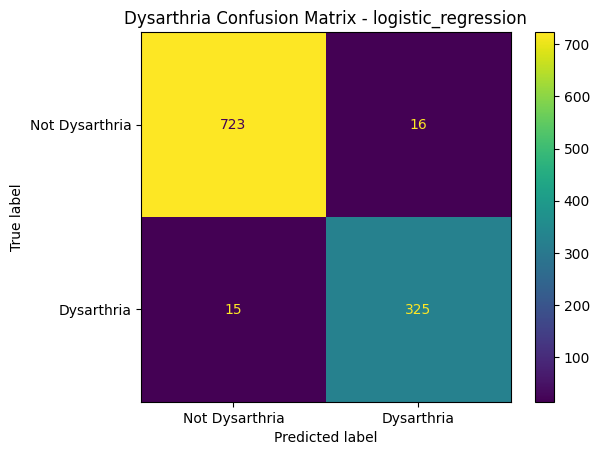

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("dysarthria confusion matrix")

best_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Dysarthria", "Dysarthria"]
)

disp.plot(values_format="d")
plt.title(f"Dysarthria Confusion Matrix - {best_name}")
plt.show()

In [5]:
# TensorFlow on this computer is broken, so this cell uses sklearn instead of TensorFlow/CNN.
# This gives a neural-network style model for Dysarthria without needing TensorFlow.

from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score
import joblib

print("dysarthria sklearn neural network section - TensorFlow skipped")

nn_model_dysarthria = Pipeline([
    ("scale", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=100,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=SEED,
    )),
])

nn_model_dysarthria.fit(X_train, y_train)
y_pred_dysarthria_nn = nn_model_dysarthria.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_dysarthria_nn)
balanced_acc = balanced_accuracy_score(y_test, y_pred_dysarthria_nn)

print("\n=== DYSARTHRIA SKLEARN NEURAL NETWORK RESULTS ===")
print("Accuracy:", round(float(accuracy), 4))
print("Balanced accuracy:", round(float(balanced_acc), 4))
print(classification_report(y_test, y_pred_dysarthria_nn))

joblib.dump(nn_model_dysarthria, MODELS_DIR / "dysarthria_sklearn_nn_model.joblib")
print("Saved:", MODELS_DIR / "dysarthria_sklearn_nn_model.joblib")

dysarthria sklearn neural network section - TensorFlow skipped

=== DYSARTHRIA SKLEARN NEURAL NETWORK RESULTS ===
Accuracy: 0.9666
Balanced accuracy: 0.9606
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       739
           1       0.95      0.94      0.95       340

    accuracy                           0.97      1079
   macro avg       0.96      0.96      0.96      1079
weighted avg       0.97      0.97      0.97      1079

Saved: c:\Users\vipra\OneDrive\Documents\GitHub\Audio-Based-Neurological-Disease-Detection-Project\Models\dysarthria_sklearn_nn_model.joblib


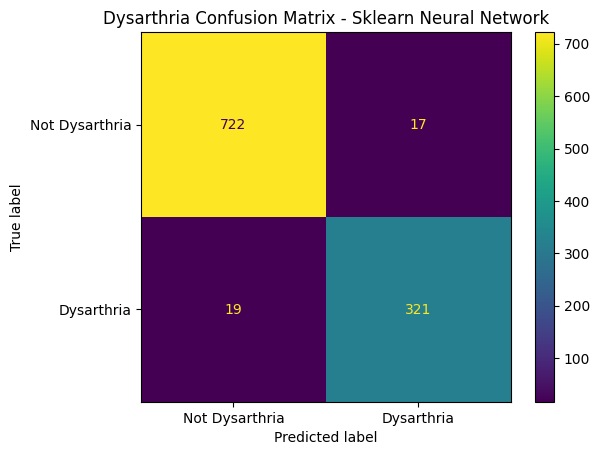

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dysarthria_nn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Dysarthria", "Dysarthria"]
)

disp.plot(values_format="d")
plt.title(f"Dysarthria Confusion Matrix - Sklearn Neural Network")
plt.show()